# Lab Assignment Four: Multi-Layer Perceptron

**Team Members:**
| Role | Name |
|---|---|
| Teammate 1 — Data Pipeline & Setup | |
| Teammate 2 — Preprocessing & 3-Layer MLP | Emilio Munoz|
| Teammate 3 — Deep Networks & Adaptive Learning | |

**Dataset:** ACS 2017 US Census Tract Data  
**Task:** Predict child poverty rate (4-class classification)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

---
## 1. Load, Split & Balance

### 1.1 Load & Clean

In [5]:
df = pd.read_csv('acs2017_census_tract_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (74001, 37)


,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,Alabama,Autauga County,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,Alabama,Autauga County,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,Alabama,Autauga County,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,Alabama,Autauga County,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,Alabama,Autauga County,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3


In [6]:
df = df.dropna()
print('No NaN Shape:', df.shape)

No NaN Shape: (72718, 37)


In [7]:
string_cols = df.select_dtypes(include=['object']).columns.tolist()
print('String columns:', string_cols)

#encodes string columns to integers
le = LabelEncoder()
for col in string_cols:
    df[col] = le.fit_transform(df[col])

df.head()

String columns: ['State', 'County']


/var/folders/nb/hm103m4s4gn2lq5pjs_ypd7w0000gn/T/ipykernel_13954/446206272.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns.tolist()


,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,0,89,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,0,89,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,0,89,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,0,89,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,0,89,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3


### 1.2 County Variable Decision

**Discussion:** *(Should the `County` variable be kept or removed? Explain your reasoning.)*

I believe that the County variable should be kept. The dataset is a 2017 compilation of geographic and socioeconomic information collected across around 74,000 census tracts across the U.S. The dataset has 37 columns, each of which has information on geographic identifiers, population spread, race & ethnicity, transportation to work, employment, etc. The county column is a great indicator of a specific geoegraphical region, which could be helpful in understanding and analyzing different trends and patterns. Geography is generally a good indication of poverty and starvation, so having counties would likely help deduce more specific geographical locations where poverty is higher/more of a concern. Also, keeping county should add as an extra predictive column that will capture patterns in which other variables may miss. 

It is also reasonable to discuss how including county would cause some potential issues with the model. For example, because there are many distinct counties, this serves as an ID problem. Because the assignment asks us to one-hot encode later on, we already know that we'll get a few thousand new columns, which could confuse our model. 

In [8]:
#Decided to keep country 
print('Columns:', df.columns.tolist())

Columns: ['TractId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment']


### 1.3 Quantize Target & Balance Dataset

Class distribution:
ChildPovertyClass
0    18229
1    18171
2    18148
3    18170
Name: count, dtype: int64


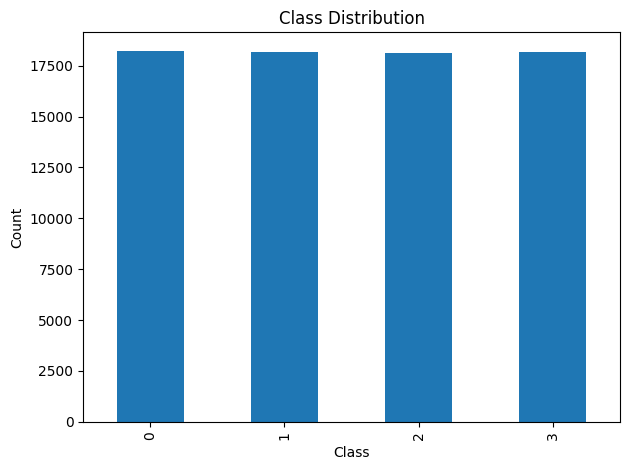

In [9]:
#Splits ChildPoverty column into 4 equally sized classes using quartile thresholids (qcut)
df['ChildPovertyClass'] = pd.qcut(df['ChildPoverty'], q=4, labels=[0, 1, 2, 3]).astype(int)

#Verficiation
print('Class distribution:')
print(df['ChildPovertyClass'].value_counts().sort_index())

#visualization
df['ChildPovertyClass'].value_counts().sort_index().plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Discussion:** *(Should balancing be applied to both the training set and the test set? Explain.)*

Balancing should only be applied to the training set. Balancing is used to prevent models from being biased toward predicting a majority class. If balancing was applied to the testing set as well, it would skew accuracy metrics since the model should perform on real, unseen data. Balancing on testing data would cause inaccurate and misleading results, as models could perform very poorly on unbalanced data compared to balanced data. 

### 1.4 Train/Test Split (80/20)

In [10]:
#Define feature columns
#Excluded 'ChildPoverty' (original continuous target), 'ChildPovertyClass' (binned target), and 'TractId' (identifier)
feature_cols = [c for c in df.columns if c not in ['ChildPoverty', 'ChildPovertyClass', 'TractId']]
categorical_col_names = ['State', 'County']  # label-encoded categorical columns
all_cols = feature_cols

# Extract features and labels
X = df[feature_cols].values
y = df['ChildPovertyClass'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)
print('Features:   ', all_cols)

Train shape: (58174, 35)
Test shape:  (14544, 35)
Features:    ['State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment']


In [11]:
#one hot encoding 
Y_train = np.eye(4)[y_train]
Y_test  = np.eye(4)[y_test]

print('Y_train shape:', Y_train.shape) 
print('Y_test shape: ', Y_test.shape)   

Y_train shape: (58174, 4)
Y_test shape:  (14544, 4)


---
## 2. MLP Helper Functions & Base Classes

In [12]:
#Example adapted from https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
#Original Author: Sebastian Raschka

import numpy as np
from scipy.special import expit
import sys
import pandas as pd

# start with a simple base classifier, which can't be fit or predicted
# it only has internal classes to be used by classes that will subclass it
# Start with the following functions:
#    init
#    encode_labels
#    initialize weights
#    sigmoid
#    add bias (vector of ones)
#    objective function (cost and regularizer)
class TwoLayerPerceptronBase(object):
    def __init__(self, n_hidden=30,
                 C=0.0, epochs=500, eta=0.001, random_state=None):
        np.random.seed(random_state)
        self.n_hidden = n_hidden
        self.l2_C = C
        self.epochs = epochs
        self.eta = eta
        
    @staticmethod
    def _encode_labels(y):
        """Encode labels into one-hot representation"""
        onehot = pd.get_dummies(y).values.T
            
        return onehot

    def _initialize_weights(self):
        """Initialize weights with small random numbers."""
        W1_num_elems = (self.n_features_ + 1)*self.n_hidden
        W1 = np.random.uniform(-1.0, 1.0, size=W1_num_elems)
        W1 = W1.reshape(self.n_hidden, self.n_features_ + 1) # reshape to be W
        
        W2_num_elems = (self.n_hidden + 1)*self.n_output_
        W2 = np.random.uniform(-1.0, 1.0, size=W2_num_elems)
        W2 = W2.reshape(self.n_output_, self.n_hidden + 1)
        return W1, W2
    
    @staticmethod
    def _sigmoid(z):
        """Use scipy.special.expit to avoid overflow"""
        # 1.0 / (1.0 + np.exp(-z))
        return expit(z)
    
    @staticmethod
    def _add_bias_unit(X, how='column'):
        """Add bias unit (column or row of 1s) to array at index 0"""
        if how == 'column':
            ones = np.ones((X.shape[0], 1))
            X_new = np.hstack((ones, X))
        elif how == 'row':
            ones = np.ones((1, X.shape[1]))
            X_new = np.vstack((ones, X))
        return X_new
    
    @staticmethod
    def _L2_reg(lambda_, W1, W2):
        """Compute L2-regularization cost"""
        # only compute for non-bias terms
        return (lambda_) * np.sqrt(np.mean(W1[:, 1:] ** 2) + np.mean(W2[:, 1:] ** 2))
    
    def _cost(self,A3,Y_enc,W1,W2):
        '''Get the objective function value'''
        cost = np.mean((Y_enc-A3)**2)
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        return cost + L2_term
# now let's add in the following functions:
#    feedforward
#    fit and predict
class TwoLayerPerceptron(TwoLayerPerceptronBase):
    def _feedforward(self, X, W1, W2):
        """Compute feedforward step
        -----------
        X : Input layer with original features.
        W1: Weight matrix for input layer -> hidden layer.
        W2: Weight matrix for hidden layer -> output layer.
        ----------
        a1-a3 : activations into layer (or output layer)
        z1-z2 : layer inputs 

        """
        A1 = self._add_bias_unit(X.T, how='row')
        Z1 = W1 @ A1
        A2 = self._sigmoid(Z1)
        A2 = self._add_bias_unit(A2, how='row')
        Z2 = W2 @ A2
        A3 = self._sigmoid(Z2)
        return A1, Z1, A2, Z2, A3
    
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # need to vectorize this computation!
        # See additional code and derivation below!
    
    def predict(self, X):
        """Predict class labels"""
        _, _, _, _, A3 = self._feedforward(X, self.W1, self.W2)
        y_pred = np.argmax(A3, axis=0)
        return y_pred
    
    
    def fit(self, X, y, print_progress=False):
        """ Learn weights from training data."""
        
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):

            if print_progress>0 and (i+1)%print_progress==0:
                sys.stderr.write('\rEpoch: %d/%d' % (i+1, self.epochs))
                sys.stderr.flush()

            # feedforward all instances
            A1, Z1, A2, Z2, A3 = self._feedforward(X_data,self.W1,self.W2)
            
            cost = self._cost(A3,Y_enc,self.W1,self.W2)
            self.cost_.append(cost)

            # compute gradient via backpropagation
            grad1, grad2 = self._get_gradient(A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2, Y_enc=Y_enc,
                                              W1=self.W1, W2=self.W2)

            self.W1 -= self.eta * grad1
            self.W2 -= self.eta * grad2
            

        return self
class TwoLayerPerceptronVectorized(TwoLayerPerceptron):
    # just need a different gradient calculation
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V2 = -2*(Y_enc-A3)*A3*(1-A3)
        V1 = A2*(1-A2)*(W2.T @ V2)
        
        grad2 = V2 @ A2.T
        grad1 = V1[1:,:] @ A1.T
        
        
        # regularize weights that are not bias terms
        grad1[:, 1:] += W1[:, 1:] * self.l2_C
        grad2[:, 1:] += W2[:, 1:] * self.l2_C

        return grad1, grad2
# Example adapted from https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
# Original Author: Sebastian Raschka
# This is the optional book we use in the course, excellent intuitions and straightforward programming examples
# please note, however, that this code has been manipulated to reflect our assumptions and notation.
class TLPVectorizedMiniBatch(TwoLayerPerceptronVectorized):
    def __init__(self, alpha=0.1, decrease_const=0.0, shuffle=True, minibatches=1, **kwds):        
        # need to add to the original initializer 
        self.alpha = alpha
        self.decrease_const = decrease_const
        self.shuffle = shuffle
        self.minibatches = minibatches
        
        
        
        # but keep other keywords
        super().__init__(**kwds)

    def fit(self, X, y, print_progress=0):
        """ Learn weights from training data."""
        if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
            X_data, y_data = X.copy().values, y.copy()
        else:
            X_data, y_data = X.copy(), y.copy()

        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2 = self._initialize_weights()
        
        # start momentum at zero for previous updates
        rho_W1_prev = np.zeros(self.W1.shape) # for momentum
        rho_W2_prev = np.zeros(self.W2.shape) # for momentum

        self.cost_ = []
        for k in range(self.epochs):

            # adaptive learning rate
            eta = self.eta**(1+self.decrease_const*k)# decreasing learning rate
            eta = max(eta,self.eta/1000)
            # there are many forms of adaptive learning rates out there!

            if print_progress>0 and (k+1)%print_progress==0:
                sys.stderr.write('\rEpoch: %d/%d' % (k+1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            # use numpy split to split into equal sized batches 
            # num batches== self.minibatches
            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            for idx in mini:

                # feedforward
                A1, Z1, A2, Z2, A3 = self._feedforward(X_data[idx],
                                                       self.W1,
                                                       self.W2)
                
                cost = self._cost(A3,Y_enc[:, idx],self.W1,self.W2)
                mini_cost.append(cost) # this appends cost of mini-batch only

                # compute gradient via backpropagation
                grad1, grad2 = self._get_gradient(A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2,
                                                  Y_enc=Y_enc[:, idx],
                                                  W1=self.W1, W2=self.W2)

                rho_W1, rho_W2 = eta * grad1, eta * grad2
                self.W1 -= (rho_W1 + (self.alpha * rho_W1_prev)) # update with momentum
                self.W2 -= (rho_W2 + (self.alpha * rho_W2_prev)) # update with momentum
                rho_W1_prev, rho_W2_prev = rho_W1, rho_W2

            self.cost_.append(mini_cost)
            
        return self



class TLPVectorizedMiniBatchCrossEntropyGlorot(TLPVectorizedMiniBatch):
    """Uses Initialize Weights"""
    

    def _initialize_weights(self):
        """Initialize weights Glorot and He normalization."""
        init_bound = 4*np.sqrt(6. / (self.n_hidden + self.n_features_ + 1))
        W1 = np.random.uniform(-init_bound, init_bound,(self.n_hidden, self.n_features_ + 1))
        W1[:,:1] = 0
        
        # reduce the final layer magnitude in order to balance the size of the gradients
        # between 
        init_bound = 4*np.sqrt(6 / (self.n_output_ + self.n_hidden + 1))
        W2 = np.random.uniform(-init_bound, init_bound,(self.n_output_, self.n_hidden + 1)) 
        W2[:,:1] = 0
        
        return W1, W2
    
    
    """Cost function that uses cross entropy"""
    def _cost(self,A3,Y_enc,W1,W2):
        '''Get the objective function value'''
        # cost = -np.mean(np.nan_to_num((Y_enc*np.log(A3)+(1-Y_enc)*np.log(1-A3))))
        # L2_term = self._L2_reg(self.l2_C, W1, W2)
        
        eps = 1e-7
        A3 = np.clip(A3, eps, 1 - eps)
        cost = -np.mean(Y_enc * np.log(A3 + eps) + (1 - Y_enc) * np.log(1 - A3 + eps))
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        return cost + L2_term
    
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V2 = (A3-Y_enc) # <- this is only line that changed
        V1 = A2*(1-A2)*(W2.T @ V2)
        
        grad2 = V2 @ A2.T
        grad1 = V1[1:,:] @ A1.T
        
        # regularize weights that are not bias terms
        grad1[:, 1:] += W1[:, 1:] * self.l2_C
        grad2[:, 1:] += W2[:, 1:] * self.l2_C

        return grad1, grad2
    

In [13]:
# Function to convert data into format to test accuracy with
def convert_data(y_pred):
  returnMe = pd.DataFrame()
  
  returnMe['first_quartile'] = (y_pred == 0)
  returnMe['second_quartile'] = (y_pred == 1)
  returnMe['third_quartile'] = (y_pred == 2)
  returnMe['fourth_quartile'] = (y_pred == 3)

  return returnMe

---
## 3. Pre-processing & Initial Modeling

### Model 1 — No Normalization, No One-Hot Encoding

Epoch: 100/100

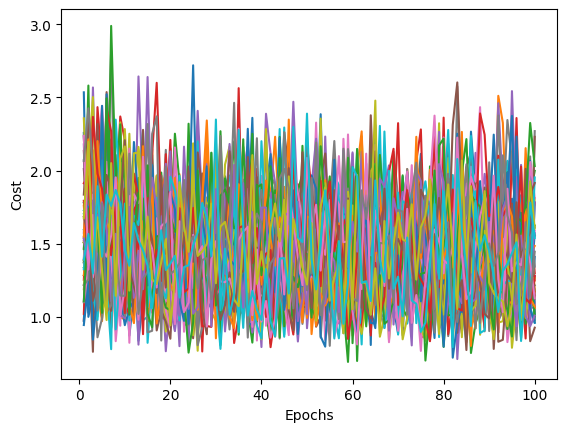

Accuracy: 0.24986248624862487


In [45]:
# train the model
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score

params = { 'n_hidden':30, 
         'C':0.1, 'epochs':100, 'eta':0.001, 
         'alpha':0.001, 'decrease_const':1e-5, 'minibatches':50,
         'shuffle':True,'random_state':1}
# model = TLPVectorizedMiniBatchCrossEntropyGlorot(n_hidden=30, C=0.0, epochs=50, eta=0.001, random_state=42)
mlp1 = TLPVectorizedMiniBatchCrossEntropyGlorot(**params)
mlp1.fit(X_train, y_train, print_progress=True)
# plot the loss over time to ensure convergence
plt.plot(range(1, len(mlp1.cost_)+1), mlp1.cost_)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

# evaluate the mlp1 on the test set
y_pred = mlp1.predict(X_test)

# Get accuracy
acc1_test = accuracy_score(y_test, y_pred)
print("Accuracy:", acc1_test)

### Model 2 — Normalize Continuous Features

In [46]:
cont_indices = [i for i, col in enumerate(all_cols) if col not in categorical_col_names]
print(f'{len(cont_indices)} continuous features, {len(all_cols) - len(cont_indices)} categorical')

scaler = StandardScaler()
X_train_norm = X_train.copy().astype(float)
X_test_norm  = X_test.copy().astype(float)
X_train_norm[:, cont_indices] = scaler.fit_transform(X_train[:, cont_indices])
X_test_norm[:,  cont_indices] = scaler.transform(X_test[:, cont_indices])

33 continuous features, 2 categorical


Epoch: 100/100

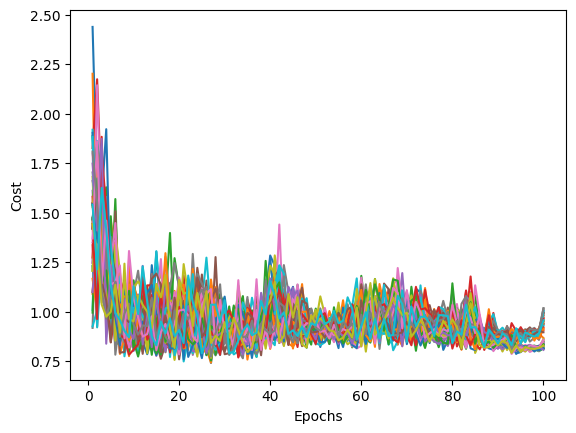

Accuracy: 0.2544004400440044


In [47]:
mlp2 = TLPVectorizedMiniBatchCrossEntropyGlorot(**params)
mlp2.fit(X_train_norm, y_train, print_progress=True)
# plot the loss over time to ensure convergence
plt.plot(range(1, len(mlp2.cost_)+1), mlp2.cost_)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

# evaluate the mlp2 on the test set
y_pred = mlp2.predict(X_test_norm)

# Get accuracy
acc2_test = accuracy_score(y_test, y_pred)
print("Accuracy:", acc2_test)

### Model 3 — Normalize Continuous + One-Hot Encode Categorical

In [48]:
cat_indices = [i for i, col in enumerate(all_cols) if col in categorical_col_names]
all_X = np.vstack([X_train, X_test])

def build_ohe(X_norm, cat_idx, all_X):
    cont_idx = [i for i in range(X_norm.shape[1]) if i not in cat_idx]
    parts = [X_norm[:, cont_idx]]
    for i in cat_idx:
        n_cats = int(all_X[:, i].max()) + 1
        parts.append(np.eye(n_cats)[X_norm[:, i].astype(int)])
    return np.hstack(parts)

X_train_ohe = build_ohe(X_train_norm, cat_indices, all_X)
X_test_ohe  = build_ohe(X_test_norm,  cat_indices, all_X)
print('X_train_ohe shape:', X_train_ohe.shape)

X_train_ohe shape: (58174, 2039)


Epoch: 100/100

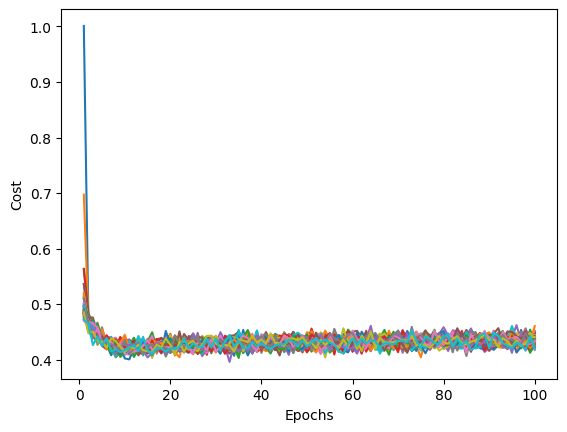

Accuracy: 0.7266914191419142


In [49]:
mlp3 = TLPVectorizedMiniBatchCrossEntropyGlorot(**params)
mlp3.fit(X_train_ohe, y_train, print_progress=True)
# plot the loss over time to ensure convergence
plt.plot(range(1, len(mlp3.cost_)+1), mlp3.cost_)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

# evaluate the mlp3 on the test set
y_pred = mlp3.predict(X_test_ohe)

# Get accuracy
acc3_test = accuracy_score(y_test, y_pred)
print("Accuracy:", acc3_test)

### Comparison: Models 1–3

               Model  Test Accuracy
1 — No Preprocessing       0.249862
      2 — Normalized       0.254400
3 — Normalized + OHE       0.726691


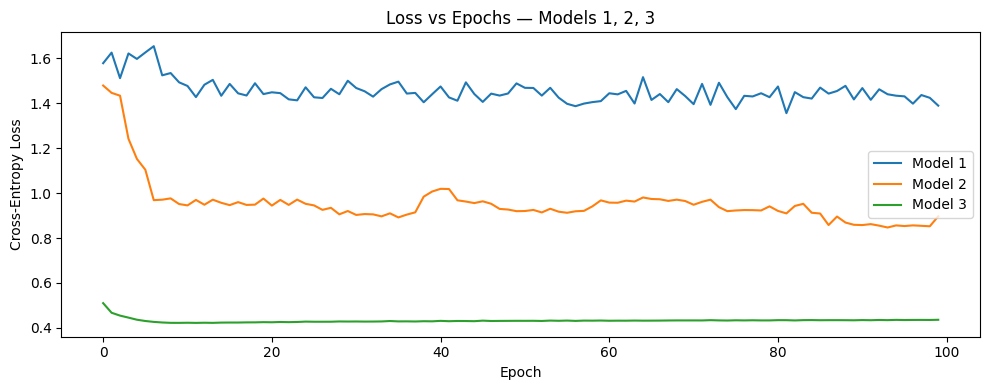

In [50]:
flat1 = [np.mean(epoch) for epoch in mlp1.cost_]
flat2 = [np.mean(epoch) for epoch in mlp2.cost_]
flat3 = [np.mean(epoch) for epoch in mlp3.cost_]

results = pd.DataFrame({
    'Model':         ['1 — No Preprocessing', '2 — Normalized', '3 — Normalized + OHE'],
    'Test Accuracy': [acc1_test, acc2_test, acc3_test]
})
print(results.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(flat1, label='Model 1')
plt.plot(flat2, label='Model 2')
plt.plot(flat3, label='Model 3')
plt.title('Loss vs Epochs — Models 1, 2, 3')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion — Comparing Models 1, 2, and 3

There were pretty clear differences between the three models. Model 1 performed the worst with a test accuracy of ~25%, which is barely above random chance for a 4-class problem. The loss curve was noisy and unstable, oscillating between 1.4-1.6 the entire time without really converging. This makes sense since the raw features are on completely different scales, so the gradients end up being skewed toward those larger features and the network has a harder time learning.

Model 2 was noticeably better in terms of its loss curve, which dipped quickly from 1.4 and stabilized around 0.9, which shows that normalization significantly helped convergence. However, its test accuracy (~25.4%) was almost identical to Model 1, which was surprising. This suggests that while normalization improved training, the categorical features being label-encoded as arbitrary integers were still preventing the model from reaching high accuracies.

Model 3 added one-hot encoding on top of normalization and performed dramatically better. It achieved ~72.7% accuracy with a loss that converged quickly and leveled out around 0.4. The jump of accuracy from Model 2 to Model 3 shows that the categorical encoding was the main issue. Once the featuers State and County were represented not as meaningless integers, the model was able to identify geographic patterns that served as accurate predictors of child poverty rates.

---
## 4. Deeper MLPs with Gradient Magnitude Tracking

In [54]:
input_size = X_train_ohe.shape[1]

In [55]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(a):
    return a * (1 - a)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def glorot(fan_in, fan_out):
    limit = np.sqrt(6 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, (fan_in, fan_out))

def cross_entropy(Y_hat, Y):
    return -np.sum(Y * np.log(Y_hat + 1e-15)) / Y.shape[0]

def accuracy(Y_hat, Y):
    return np.mean(np.argmax(Y_hat, axis=1) == np.argmax(Y, axis=1))

### 3-Layer MLP

In [53]:
mlp_3L = MLPNLayer([input_size, 64, 32, output_size], lr=0.01, epochs=100)
mlp_3L.fit(X_train_ohe, Y_train)

acc_3L_train = accuracy(mlp_3L.predict(X_train_ohe), Y_train)
acc_3L_test  = accuracy(mlp_3L.predict(X_test_ohe),  Y_test)
print(f'3-Layer  |  Train: {acc_3L_train:.4f}  Test: {acc_3L_test:.4f}')

NameError: name 'MLPNLayer' is not defined

In [ ]:
plt.plot(mlp_3L.loss_history)
plt.title('3-Layer MLP — Loss vs Epochs')
plt.xlabel('Epoch');  plt.ylabel('Cross-Entropy Loss')
plt.tight_layout();  plt.show()

mlp_3L.plot_grad_magnitudes('3-Layer MLP — Gradient Magnitudes per Layer')

### 4-Layer MLP

In [ ]:
# TODO: Train a 4-layer MLPNLayer, print test accuracy,
# plot loss curve and gradient magnitudes.


### 5-Layer MLP

In [ ]:
# TODO: Train a 5-layer MLPNLayer, print test accuracy,
# plot loss curve and gradient magnitudes.


---
## 5. Adaptive Learning

In [ ]:
# TODO: Implement RMSProp or AdaDelta (not AdaM) as a subclass of MLPNLayer.
# Apply it to the 5-layer network.


In [ ]:
# TODO: Train the adaptive model, print test accuracy,
# and plot loss curves comparing SGD vs adaptive method.


**Discussion:** *(Which adaptive method did you choose and why? Compare the 5-layer SGD vs adaptive method in terms of convergence speed, final accuracy, and gradient magnitudes.)*

---
## 6. Exceptional Work

In [ ]:
# TODO: Additional analysis.
# Ideas: confusion matrix, per-class accuracy, hyperparameter sweep,
# train vs test accuracy curves, AdaM implementation (required for 7000-level)


---
## Summary

| Model | Test Accuracy |
|---|---|
| 1 — 2-layer, no preprocessing | |
| 2 — 2-layer, normalized | |
| 3 — 2-layer, normalized + OHE | |
| 3-layer MLP | |
| 4-layer MLP | |
| 5-layer MLP (SGD) | |
| 5-layer MLP (adaptive) | |